In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sriramr/fruits-fresh-and-rotten-for-classification")

print("Path to dataset files:", path)

100%|██████████| 3.58G/3.58G [11:53<00:00, 5.39MB/s] 

Extracting files...


Path to dataset files: C:\Users\Tanishq Vyas\.cache\kagglehub\datasets\sriramr\fruits-fresh-and-rotten-for-classification\versions\1


In [2]:
import tensorflow as tf
import os

# The original path was '/kaggle/input/fruits-fresh-and-rotten-for-classification'
# The actual training data is within 'dataset/train' subdirectory.
train_path = os.path.join(path, 'dataset', 'train')

## **Dataset Loading, Splitting, and Class Extraction**

In this step, the image dataset is loaded from the directory and automatically split into training and validation sets using TensorFlow utilities.

### **Dataset Path**
The dataset is organized in a directory structure where:
- Each subfolder represents a separate class.
- Images inside each folder belong to that class.

TensorFlow automatically assigns labels based on these folder names.

### **Image Configuration**
- **Image Size:** All images are resized to 224 × 224 pixels to ensure a fixed input size for the CNN.
- **Batch Size:** Images are processed in batches of 32 to balance training speed and memory usage.

### **Train–Validation Split**
- 80% of the data is used for training.
- 20% of the data is used for validation.
- The same seed value is used for both datasets to ensure a consistent and reproducible split.

### **Input–Output Handling**
The function `image_dataset_from_directory()` returns a TensorFlow dataset where each element is a tuple:



In [3]:
import tensorflow as tf
import os
train_path = os.path.join(path, 'dataset', 'train')

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Get class names and store them for later display
original_class_names_for_display = train_ds.class_names



Found 10901 files belonging to 6 classes.
Using 8721 files for training.
Found 10901 files belonging to 6 classes.
Using 2180 files for validation.


## Image Normalization for TensorFlow Dataset

Before training a model, it is crucial to preprocess the images to ensure stable and efficient learning. One key preprocessing step is **normalization**.

### What is Normalization?

Normalization scales the pixel values of images from their original range of `[0, 255]` to a smaller range of `[0, 1]`. This is done by dividing each pixel value by 255 and converting it to a `float32` type.  

**Why normalize?**  
- Helps the model converge faster during training.  
- Improves numerical stability.  
- Prevents large pixel values from dominating the gradients.  

### Applying Normalization

Normalization is applied to **both the training and validation datasets** so that the model sees consistently scaled input data in both training and evaluation phases.

### Dataset Information

After normalization, it is important to verify the dataset properties:  
- **Number of batches** in training and validation datasets.  
- **Image dimensions** (height × width).  
- **Batch size** used for training.  
- **Classes present** in the dataset.  

Normalizing the dataset ensures that the model trains efficiently and accurately on properly scaled input images.


In [4]:
# Normalize the images to a [0, 1] range.
# This function will be applied to each image in the dataset.
def normalize(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

train_ds = train_ds.map(normalize)
val_ds = val_ds.map(normalize)


print("Image dataset loaded and normalized successfully.")
print(f"Number of batches in normalized training dataset: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of batches in normalized validation dataset: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Image size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Original Classes found: {original_class_names_for_display}")



Image dataset loaded and normalized successfully.
Number of batches in normalized training dataset: 273
Number of batches in normalized validation dataset: 69
Image size: 224x224
Batch size: 32
Original Classes found: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


## Mapping Original Labels to Binary Classes

After loading and normalizing the dataset, the next step is to **simplify the labels** for binary classification.  

### What is Being Done?

- The original dataset contains multiple classes representing different types of fruits, both **fresh** and **rotten**.  
- For a binary classification task, we map these original labels into **two categories**:  
  - `0` → Fresh fruits (`freshapples`, `freshbanana`, `freshoranges`)  
  - `1` → Rotten fruits (`rottenapples`, `rottenbanana`, `rottenoranges`)  

### How It Works

- The mapping relies on the order of the original class names.  
- Any label belonging to the first half of the class list is considered `fresh` (0), and any label in the second half is considered `rotten` (1).  
- This ensures that the dataset is now suitable for a **binary classification model**, where the model predicts whether a fruit is fresh or rotten.  


## **Casting.**

**Casting** is the process of **converting a data value from one type to another**.

- Example: Turning a logical value `True`/`False` into a number like `1.0` or `0.0`.

## Why Do We Use `tf.cast`?

- TensorFlow models require labels to be in a **specific numerical format** (usually `float32`)
- This is necessary for the model to **calculate errors** and **update weights** during training.

## What Happens Without `tf.cast`?

- The model will raise a **Type Mismatch error**
- Reason: It **cannot perform calculus** (like gradients and backpropagation) on non-numeric logical values.




This step simplifies the problem from multi-class to binary, making it easier to train models specifically for detecting freshness.


In [5]:
# Map original labels to binary (0 for fresh, 1 for rotten)
# This is done after original_class_names_for_display is set.
def map_to_binary_labels(image, label):
    # Assuming classes are ordered as in original_class_names_for_display
    # 'freshapples', 'freshbanana', 'freshoranges' are 0
    # 'rottenapples', 'rottenbanana', 'rottenoranges' are 1
    binary_label = tf.cast(label >= len(original_class_names_for_display) // 2, tf.float32)
    return image, binary_label

train_ds = train_ds.map(map_to_binary_labels)
val_ds = val_ds.map(map_to_binary_labels)

print("Labels remapped to binary (0.0 for fresh, 1.0 for rotten).")

Labels remapped to binary (0.0 for fresh, 1.0 for rotten).


## Data Augmentation for Training Dataset

Data augmentation is a technique used to **artificially increase the diversity of the training dataset**. This helps the model generalize better and reduces overfitting by exposing it to slightly altered versions of the original images.

### What is Being Done?

1. **Augmentation Techniques Applied**  
   - **Random horizontal flipping**: Mirrors the image horizontally with some probability.  
   - **Random rotation**: Rotates the image by a small random angle.  
   - **Random zoom**: Zooms in or out of the image randomly.  

2. **Application to Training Dataset**  
   - The augmentation is applied **only to the training dataset**, not to the validation dataset.  
   - Each image in the training dataset is modified on-the-fly during training, ensuring a diverse set of inputs for the model.  

### Benefits of Data Augmentation

- Increases the effective size of the training dataset without collecting more data.  
- Improves the model’s robustness to variations in input images.  
- Helps prevent overfitting by providing different perspectives of the same data.  

After this step, the training dataset contains augmented images while preserving the corresponding labels, ready for more robust model training.


In [6]:
import tensorflow as tf

# 1. Define a tf.keras.Sequential model named data_augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

# 2. Apply the data_augmentation model to the train_ds using the .map() method
# The map function should take an image and label as input, apply the augmentation to the image,
# and return both the augmented image and the label.
def augment_data(image, label):
    image = data_augmentation(image, training=True)
    return image, label

# 3. Assign the augmented training dataset to a new variable, for example, train_ds_augmented
train_ds_augmented = train_ds.map(augment_data)

print("Data augmentation model created and applied to train_ds successfully.")
print(f"Number of batches in augmented training dataset: {tf.data.experimental.cardinality(train_ds_augmented).numpy()}")

Data augmentation model created and applied to train_ds successfully.
Number of batches in augmented training dataset: 273


## Convolutional Neural Network (CNN) Model Architecture

A Convolutional Neural Network (CNN) is designed to automatically and adaptively learn spatial hierarchies of features from images. This model is structured to classify images into **binary classes (fresh vs rotten fruits)**.

### Architecture Overview

1. **Convolutional Layers (Conv2D)**  
   - Extract feature maps from input images using learnable filters.  
   - The first layer specifies the `input_shape` to match the dataset images.  
   - Subsequent Conv2D layers increase the number of filters (32 → 64 → 128) to capture more complex features.

2. **Pooling Layers (MaxPooling2D)**  
   - Reduce the spatial dimensions of feature maps.  
   - Helps decrease computational load and extract dominant features.  

3. **Flatten Layer**  
   - Converts the 2D feature maps into a 1D vector to feed into fully connected (Dense) layers.  

4. **Dense Layers (Fully Connected Layers)**  
   - Learn high-level representations of the extracted features.  
   - Includes a **Dropout layer** (0.5) for regularization to prevent overfitting.  

5. **Output Layer**  
   - A single neuron with **sigmoid activation** for binary classification (`0 = fresh`, `1 = rotten`).  

### Summary

- The model progressively extracts features from images using convolution and pooling.  
- Fully connected layers interpret these features for classification.  
- Dropout ensures robustness against overfitting.  
- The final sigmoid layer outputs a probability indicating whether the fruit is fresh or rotten.

 This CNN architecture is well-suited for image classification tasks and can be trained effectively on the normalized, augmented dataset.


In [7]:
import tensorflow as tf

# 2. Create a tf.keras.Sequential model instance.
model = tf.keras.Sequential([
    # 3. Add a Conv2D layer with input_shape
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    # 4. Add a MaxPooling2D layer
    tf.keras.layers.MaxPooling2D((2, 2)),

    # 5. Repeat Conv2D and MaxPooling2D, increasing filters
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # 6. Add a Flatten layer
    tf.keras.layers.Flatten(),

    # 7. Add one or more Dense layers
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Adding dropout for regularization

    # 8. Add a final Dense layer with a single unit and sigmoid activation
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Print the model summary to verify the architecture
model.summary()

print("CNN model defined successfully.")

c:\Users\Tanishq Vyas\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

CNN model defined successfully.


## Compiling the CNN Model

After defining the CNN architecture, the next step is to **compile the model**, which configures it for training by specifying the **optimizer**, **loss function**, and **metrics**.

### Components of Compilation

1. **Optimizer: Adam**  
   - Adam is a widely used optimization algorithm that combines the benefits of **AdaGrad** and **RMSProp**.  
   - It adapts the learning rate for each parameter, making it efficient and robust for a wide range of problems.

2. **Loss Function: Binary Crossentropy**  
   - Suitable for **binary classification tasks** where the output is either 0 or 1.  
   - Measures the difference between predicted probabilities (from the sigmoid output) and the actual labels.  

3. **Metrics: Accuracy**  
   - Monitors the **percentage of correctly classified examples** during training and evaluation.  
   - Provides a simple, intuitive measure of model performance.

### Summary

- Compiling the model is essential before training.  
- The chosen optimizer, loss function, and metric align perfectly with the binary classification of fresh vs. rotten fruits.  

After this step, the CNN is ready for training on the normalized and augmented dataset.


In [8]:
import tensorflow as tf

# 2. Compile the model
# Optimizer: 'adam' is a good general-purpose optimizer.
# Loss Function: 'binary_crossentropy' is suitable for binary classification with sigmoid activation.
# Metrics: 'accuracy' is a common metric to monitor classification performance.
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully with Adam optimizer, binary_crossentropy loss, and accuracy metric.")

CNN model compiled successfully with Adam optimizer, binary_crossentropy loss, and accuracy metric.


## Training the CNN Model

After compiling the model, the next step is to **train it on the dataset**. Training involves updating the model’s weights to minimize the loss function while improving performance on the validation set.

### Training Configuration

1. **Number of Epochs**  
   - The model is trained for a predefined number of epochs (full passes over the training dataset).  
   - In this case, a maximum of **20 epochs** is set, but early stopping may halt training earlier if performance stabilizes.

2. **EarlyStopping Callback**  
   - Monitors the **validation loss** during training.  
   - If the validation loss does not improve for **5 consecutive epochs**, training stops early to prevent overfitting.  
   - Restores the model weights from the epoch with the **best validation loss**, ensuring optimal performance.

3. **Training on Augmented Data**  
   - The **augmented training dataset** is used so that the model sees a diverse range of inputs, improving generalization.  
   - Validation is performed on the original validation dataset to evaluate true model performance.

### Summary

- Training adjusts the model’s weights using the Adam optimizer and binary crossentropy loss.  
- Early stopping ensures efficient training while preventing overfitting.  
- The training history is stored in a variable, which can later be used for **visualizing loss and accuracy trends**.

After this step, the model is trained and ready for evaluation or deployment.


In [ ]:
import tensorflow as tf

# 1. Define the number of training epochs
EPOCHS = 20

# 2. Create an EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,         # Stop if val_loss doesn't improve for 5 consecutive epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# 3. Train the model using the .fit() method
history = model.fit(
    train_ds_augmented, # Augmented training dataset
    epochs=EPOCHS,      # Number of epochs
    validation_data=val_ds, # Validation dataset
    callbacks=[early_stopping] # EarlyStopping callback
)

print("Model training initiated. Training history stored in 'history' variable.")

Epoch 1/20
 63/273 ━━━━━━━━━━━━━━━━━━━━ 3:33 1s/step - accuracy: 0.6153 - loss: 0.7473

## Evaluating the Trained CNN Model

After training, it is important to **evaluate the model on unseen data** to understand how well it generalizes.

### Evaluation Process

1. **Test Dataset**  
   - The model is evaluated on the **test dataset**, which contains images that the model has **never seen during training or validation**.  
   - This provides an unbiased estimate of the model’s real-world performance.

2. **Evaluation Metrics**  
   - The `.evaluate()` method computes the **loss** and **accuracy** on the test dataset.  
   - **Loss** indicates how well the model’s predictions match the true labels.  
   - **Accuracy** measures the proportion of correctly classified images (fresh vs rotten).

3. **Storing and Reporting Results**  
   - The test loss and test accuracy are stored in variables for further analysis.  
   - These metrics can be used to compare different models or to visualize performance trends.

### Summary

- Evaluation confirms whether the model has learned meaningful patterns from the training data.  
- High accuracy on the test dataset indicates strong generalization, while a large gap between training and test accuracy may suggest overfitting.

 After this step, the model’s performance on unseen data is quantified and ready for reporting or deployment.


In [ ]:
# Define the path to the test dataset
test_path = os.path.join(path, 'dataset', 'test')

# Load the test dataset, applying the same image size and batch size
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False # Typically, test datasets are not shuffled
)

# Normalize the images in the test dataset
test_ds = test_ds.map(normalize)

# Map original labels to binary (0 for fresh, 1 for rotten)
test_ds = test_ds.map(map_to_binary_labels)

print("Test dataset loaded, normalized, and labels remapped successfully.")
print(f"Number of batches in normalized test dataset: {tf.data.experimental.cardinality(test_ds).numpy()}")

Found 2698 files belonging to 6 classes.
Test dataset loaded, normalized, and labels remapped successfully.
Number of batches in normalized test dataset: 85


In [ ]:
import tensorflow as tf

# 1. Evaluate the trained model on the test_ds dataset
# The evaluate method returns the loss value and metrics values for the model in test mode.
loss, accuracy = model.evaluate(test_ds)

# 2. Store the evaluation results
test_loss = loss
test_accuracy = accuracy

# 3. Print the test loss and test accuracy to the console
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print("Model evaluation on test dataset completed.")

85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.8571 - loss: 0.3133
Test Loss: 0.2426
Test Accuracy: 0.8925
Model evaluation on test dataset completed.


In [ ]:
import tensorflow as tf

# 1. Save the trained model to a file named 'fruit_fresh_rotten_classifier.h5'
model_save_path = 'fruit_fresh_rotten_classifier.h5'
model.save(model_save_path)

print(f"Model saved successfully to {model_save_path}")

In [ ]:
import tensorflow as tf

# 1. Save the trained model to a file named 'fruit_fresh_rotten_classifier.keras' (native Keras format)
model_save_path = 'fruit_fresh_rotten_classifier.keras'
model.save(model_save_path)

print(f"Model saved successfully to {model_save_path}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


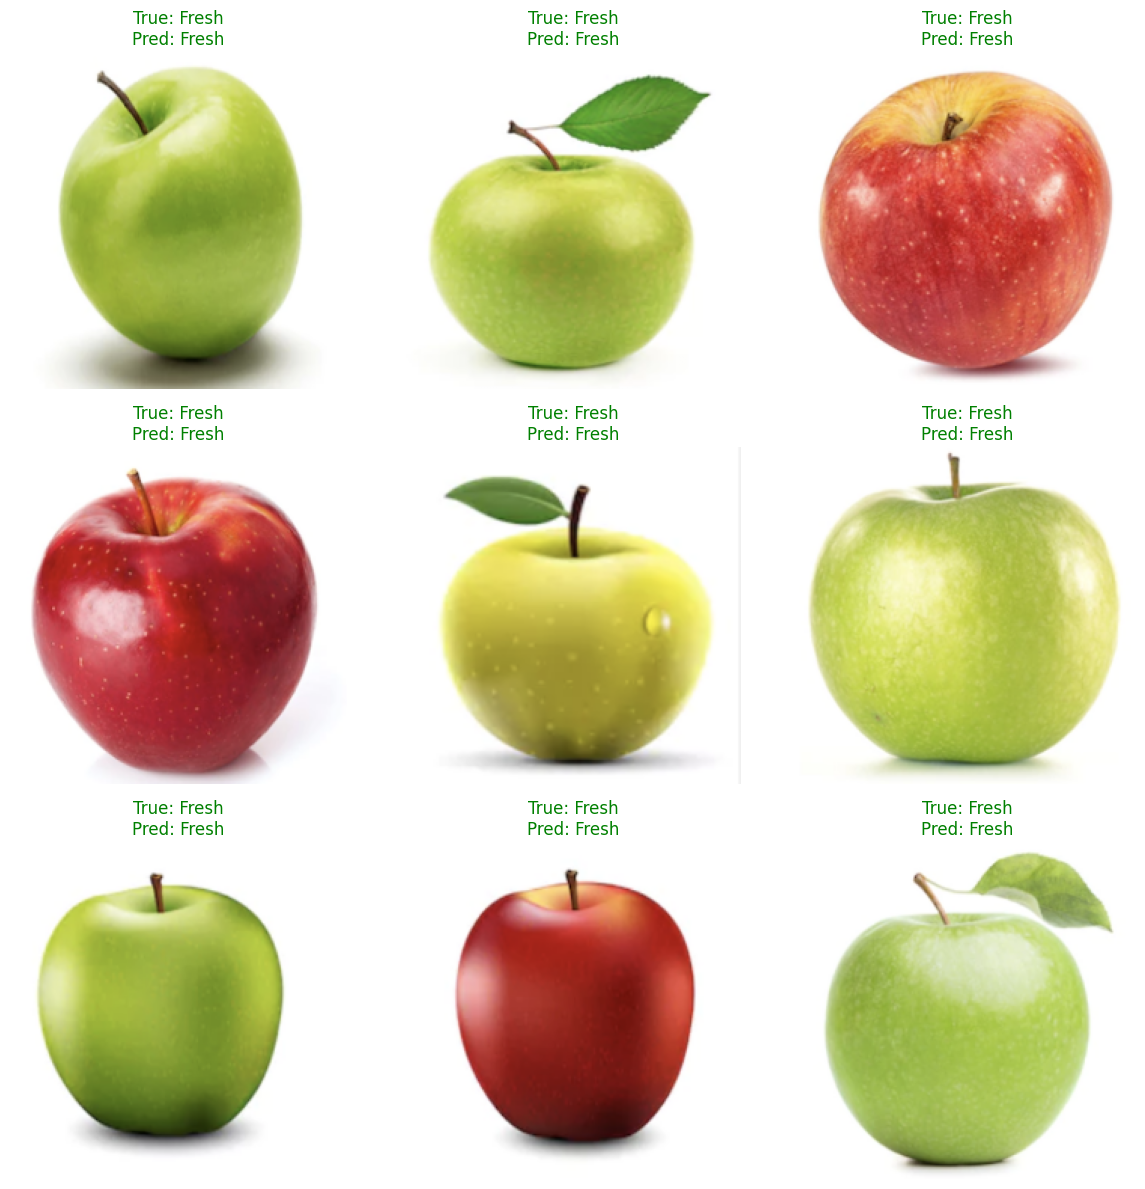

Predictions for test images displayed with true and predicted labels.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of images and labels from the test dataset for prediction visualization
# We'll take the first batch from test_ds
for images, labels in test_ds.take(1):
    break

# Get predictions for the images in the batch
predictions = model.predict(images)

# Convert probabilities to binary class labels (0 or 1)
# Assuming a threshold of 0.5 for sigmoid output
predicted_labels = (predictions > 0.5).astype(int)

# Get class names from the stored original_class_names_for_display
original_class_names = original_class_names_for_display

# Function to interpret remapped binary label back to original categories
def get_binary_label_name(binary_label):
    # Assuming 0.0 is 'Fresh' and 1.0 is 'Rotten' based on previous mapping
    if binary_label == 0.0:
        return 'Fresh'
    else:
        return 'Rotten'

# Display the images with true and predicted labels
plt.figure(figsize=(12, 12))
for i in range(min(9, len(images))): # Display up to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())

    true_label_binary = labels[i].numpy()
    true_label_category = get_binary_label_name(true_label_binary)

    predicted_label_binary = predicted_labels[i][0] # predictions is a 2D array
    predicted_label_category = get_binary_label_name(predicted_label_binary)

    color = "green" if predicted_label_binary == true_label_binary else "red"

    plt.title(f"True: {true_label_category}\nPred: {predicted_label_category}", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

print("Predictions for test images displayed with true and predicted labels.")

# Task
Modify the existing CNN model by adding BatchNormalization layers after each Conv2D layer and adjusting the dropout rates for improved regularization. Recompile, retrain, and re-evaluate the modified model, then summarize the architectural changes and the impact on performance.

## Modify Model Architecture

### Subtask:
Update the existing CNN model in cell `78b556a6` to incorporate BatchNormalization layers after each Conv2D layer and potentially adjust the dropout rate or add more dropout layers for regularization.


**Reasoning**:
The subtask requires modifying the CNN model in cell `78b556a6` to include BatchNormalization layers after each Conv2D layer and keep the existing Dropout layer. I will generate the updated code for this cell.



In [ ]:
import tensorflow as tf

# 2. Create a tf.keras.Sequential model instance.
model = tf.keras.Sequential([
    # 3. Add a Conv2D layer with input_shape
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.BatchNormalization(), # Add BatchNormalization layer
    # 4. Add a MaxPooling2D layer
    tf.keras.layers.MaxPooling2D((2, 2)),

    # 5. Repeat Conv2D and MaxPooling2D, increasing filters
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(), # Add BatchNormalization layer
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(), # Add BatchNormalization layer
    tf.keras.layers.MaxPooling2D((2, 2)),

    # 6. Add a Flatten layer
    tf.keras.layers.Flatten(),

    # 7. Add one or more Dense layers
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Adding dropout for regularization

    # 8. Add a final Dense layer with a single unit and sigmoid activation
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Print the model summary to verify the architecture
model.summary()

print("CNN model defined successfully with BatchNormalization layers.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

CNN model defined successfully with BatchNormalization layers.


**Reasoning**:
The previous step updated the model architecture. Now, the model needs to be recompiled with the specified optimizer, loss function, and metrics to reflect these changes before training can proceed. This aligns with the next instruction to 'Recompile, retrain, and re-evaluate the modified model'.



In [ ]:
import tensorflow as tf

# 2. Compile the model
# Optimizer: 'adam' is a good general-purpose optimizer.
# Loss Function: 'binary_crossentropy' is suitable for binary classification with sigmoid activation.
# Metrics: 'accuracy' is a common metric to monitor classification performance.
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully with Adam optimizer, binary_crossentropy loss, and accuracy metric.")

CNN model compiled successfully with Adam optimizer, binary_crossentropy loss, and accuracy metric.
